In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [3]:
trades.head()
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.isnull().sum()
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [5]:
trades.duplicated().sum()
sentiment.duplicated().sum()

np.int64(0)

In [6]:
# Timestamp Conversion 
trades["date"] = pd.to_datetime(trades["Timestamp"], unit="ms").dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [7]:
# Merge the datasets 
merged = trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed


In [8]:
## Key Metrics

# Daily Pnl per trader 
daily_pnl = merged.groupby(["Account", "date"])["Closed PnL"].sum().reset_index()

In [9]:
# trades per day
trades_per_day = merged.groupby("date").size().reset_index(name="trade_count")

In [10]:
# Average trade size
avg_trade_size = merged["Size USD"].mean()
print("Average Trade Size:", avg_trade_size) 

Average Trade Size: 5639.4512103738225


In [11]:
#long vs short ratio
merged["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

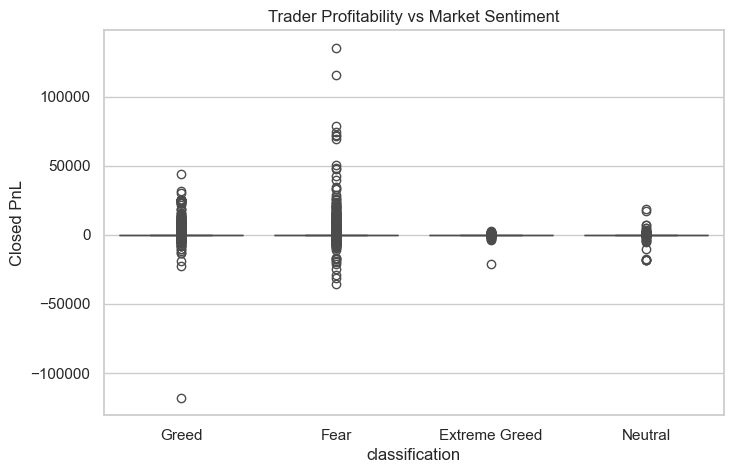

In [12]:
### Best charts
# 1.PnL Distribution by Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(x="classification", y="Closed PnL", data=merged)
plt.title("Trader Profitability vs Market Sentiment")
plt.savefig("charts/pnl_vs_sentiment.png")
plt.show()

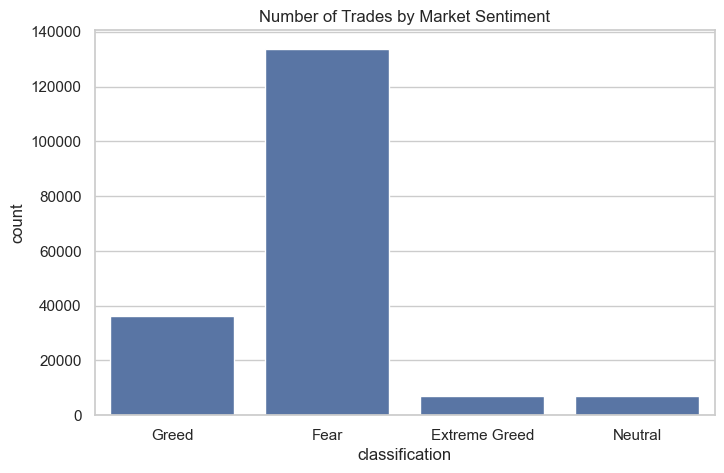

In [13]:
# 2. Trade Frequency by Sentiment
plt.figure(figsize=(8,5))
sns.countplot(x="classification", data=merged)
plt.title("Number of Trades by Market Sentiment")
plt.savefig("charts/trades_vs_sentiment.png")
plt.show()

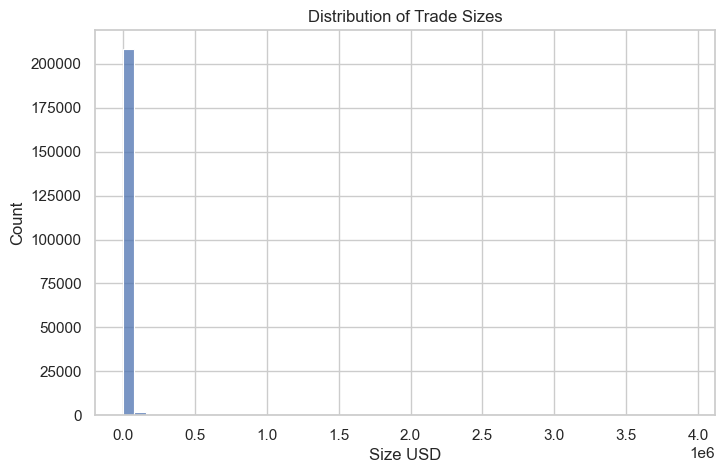

In [14]:
# 3. Trade Size Distribution
plt.figure(figsize=(8,5))
sns.histplot(merged["Size USD"], bins=50)
plt.title("Distribution of Trade Sizes")
plt.savefig("charts/trade_size_distribution.png")
plt.show()

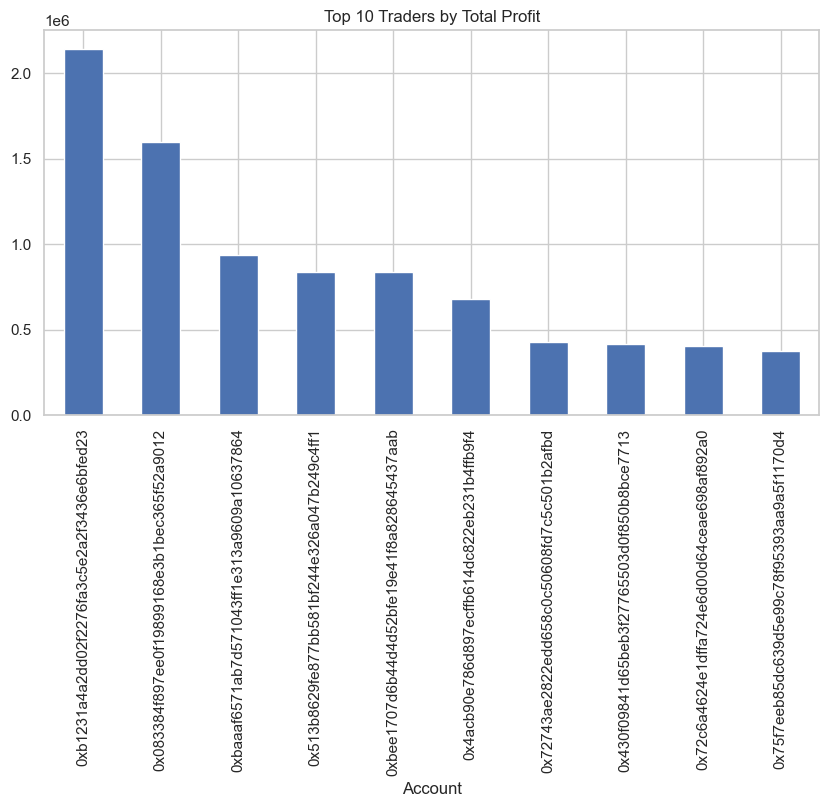

In [15]:
# 4. Top 10 Traders by Profit
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_traders.plot(kind="bar")
plt.title("Top 10 Traders by Total Profit")
plt.savefig("charts/top_traders.png")
plt.show()

In [16]:
### Trader segmentation

# High vs Low Activity Traders

trade_counts = merged.groupby("Account").size()

high_activity = trade_counts[trade_counts > 100]
low_activity = trade_counts[trade_counts <= 100]

In [18]:
# High vs Low Trade Size

high_trade_size = merged[merged["Size USD"] > merged["Size USD"].median()]
low_trade_size = merged[merged["Size USD"] <= merged["Size USD"].median()]

In [19]:
# Trader Segmentation Based on Trade Size

merged["trade_size_segment"] = pd.qcut(
    merged["Size USD"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

merged["trade_size_segment"].value_counts()

trade_size_segment
Small     70409
Large     70408
Medium    70407
Name: count, dtype: int64

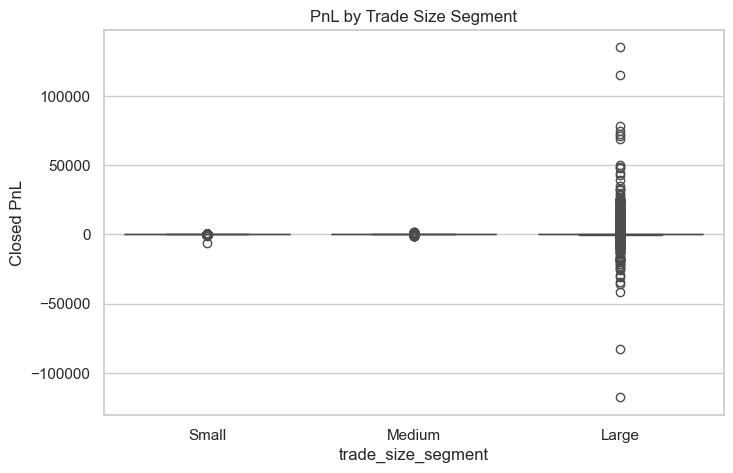

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="trade_size_segment", y="Closed PnL", data=merged)
plt.title("PnL by Trade Size Segment")
plt.show()

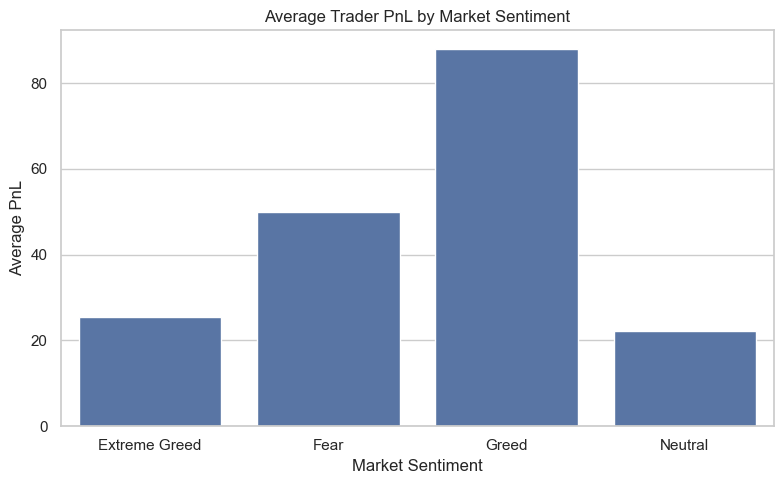

In [ ]:
### Average PnL by Market Sentiment

avg_pnl_sentiment = merged.groupby("classification")["Closed PnL"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="classification", y="Closed PnL", data=avg_pnl_sentiment)

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.tight_layout()
plt.savefig("charts/avg_pnl_sentiment.png")
plt.show()

In [23]:
### ML Model

## Create Target Variable
# We convert PnL into profit vs loss classification.

merged["profit"] = (merged["Closed PnL"] > 0).astype(int)

merged[["Closed PnL","profit"]].head()

,Closed PnL,profit
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [24]:
## Select Features


features = merged[[
    "Size USD"
]]

X = features
y = merged["profit"]

X = pd.get_dummies(merged[["Size USD","classification"]], drop_first=True)

In [25]:
## Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
## Train Random Forest Model
# Random Forest works well for tabular data.

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
## Make Predictions
predictions = model.predict(X_test)

In [28]:
## Evaluate Model

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)
print(classification_report(y_test, predictions))

Model Accuracy: 0.6001420286424429
              precision    recall  f1-score   support

           0       0.66      0.67      0.66     24802
           1       0.52      0.50      0.51     17443

    accuracy                           0.60     42245
   macro avg       0.59      0.58      0.59     42245
weighted avg       0.60      0.60      0.60     42245

